# Customer Churn Data Preprocessing


 ## Objective
This project performs data preprocessing and cleaning on a telecom customer churn dataset.

The goal is to:
- identify and handle missing values
- correct inconsistent categorical values
- standardize column names
- prepare the dataset for future machine learning modeling

In [411]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [412]:
df = pd.read_csv("../data/CHURN_TELECON_MOD08_TAREFA.csv", sep=';')
df.head()

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes


## Dataset Loading

The dataset was loaded and an initial preview was performed to understand its structure and variables.

In [413]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          2500 non-null   str    
 1   Genero              2488 non-null   str    
 2   Idoso               2500 non-null   int64  
 3   Casado              2500 non-null   str    
 4   Dependents          2500 non-null   str    
 5   Tempo_como_Cliente  2500 non-null   int64  
 6   PhoneService        1018 non-null   str    
 7   Servico_Internet    2500 non-null   str    
 8   Servico_Seguranca   2500 non-null   str    
 9   Suporte_Tecnico     2500 non-null   str    
 10  StreamingTV         2500 non-null   str    
 11  Tipo_Contrato       2500 non-null   str    
 12  PaymentMethod       2500 non-null   str    
 13  Pagamento_Mensal    2175 non-null   float64
 14  Total_Pago          2500 non-null   float64
 15  Churn               2495 non-null   str    
dtypes: float64(2), in

In [414]:
df.shape

(2500, 16)

In [415]:
df.columns

Index(['customerID', 'Genero', 'Idoso', 'Casado', 'Dependents',
       'Tempo_como_Cliente', 'PhoneService', 'Servico_Internet',
       'Servico_Seguranca', 'Suporte_Tecnico', 'StreamingTV', 'Tipo_Contrato',
       'PaymentMethod', 'Pagamento_Mensal', 'Total_Pago', 'Churn'],
      dtype='str')

## Initial Data Inspection

At this stage, data types, dimensions, and column names were inspected to understand the dataset structure.

## Missing Values Analysis

The percentage of missing values was calculated for each variable to define the most appropriate treatment strategy.

In [416]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'missing_values': missing_values,
    'missing_percentage': missing_percentage
})

missing_summary[missing_summary['missing_values'] > 0]

,missing_values,missing_percentage
Genero,12,0.48
PhoneService,1482,59.28
Pagamento_Mensal,325,13.00
Churn,5,0.20


In [417]:
df = df.dropna(subset=['Genero', 'Pagamento_Mensal', 'Churn'])

In [418]:
df.isnull().sum()

customerID               0
Genero                   0
Idoso                    0
Casado                   0
Dependents               0
Tempo_como_Cliente       0
PhoneService          1315
Servico_Internet         0
Servico_Seguranca        0
Suporte_Tecnico          0
StreamingTV              0
Tipo_Contrato            0
PaymentMethod            0
Pagamento_Mensal         0
Total_Pago               0
Churn                    0
dtype: int64

Rows containing missing values in `Genero`, `Pagamento_Mensal`, and `Churn` were removed due to their low missing rate, minimizing data loss impact.

## Imputation of Categorical Missing Values

Since `PhoneService` presented a large number of missing values, row deletion was not appropriate.
Mode imputation was chosen as the best strategy.

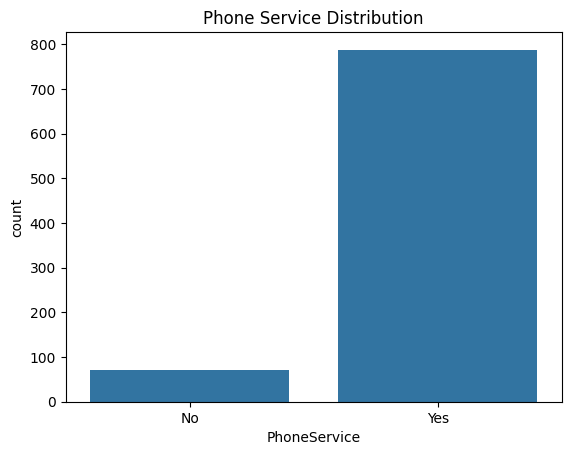

In [419]:
sns.countplot(x='PhoneService', data=df)
plt.title('Phone Service Distribution')
plt.show()

In [420]:
df['PhoneService'] = df['PhoneService'].fillna(
    df['PhoneService'].mode()[0]
)

In [421]:
df.isnull().sum()

customerID            0
Genero                0
Idoso                 0
Casado                0
Dependents            0
Tempo_como_Cliente    0
PhoneService          0
Servico_Internet      0
Servico_Seguranca     0
Suporte_Tecnico       0
StreamingTV           0
Tipo_Contrato         0
PaymentMethod         0
Pagamento_Mensal      0
Total_Pago            0
Churn                 0
dtype: int64

## Data Consistency Check

Unique categorical values were analyzed to identify inconsistent labels, spelling differences, and capitalization issues.

In [422]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f'\n{col}')
    print(df[col].unique())


customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '0895-LMRSF', '8098-LLAZX',
 '8266-VBFQL', '8181-YHCMF', '2240-HSJQD', '1248-DYXUB', '0265-EDXBD',
 ...
 '7641-TQFHN', '1552-TKMXS', '9206-GVPEQ', '8622-ZLFKO', '1596-BBVTG',
 '6188-UXBBR', '2333-KWEWW', '5702-SKUOB', '1134-YWTYF', '6061-GWWAV']
Length: 2175, dtype: str

Genero
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Casado
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Servico_Internet
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

Servico_Seguranca
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Suporte_Tecnico
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingTV
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Tipo_Contrato
<StringArray>
['Month-to-month', 'One year', 'T

C:\Users\julia\AppData\Local\Temp\ipykernel_24520\2480384803.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


In [423]:
df['Genero'] = df['Genero'].replace({
    'M': 'Male',
    'F': 'Female',
    'f': 'Female'
})

df['Servico_Internet'] = df['Servico_Internet'].replace({
    'dsl': 'DSL'
})

In [424]:
print(df['Genero'].value_counts())
print(df['Servico_Internet'].value_counts())

Genero
Male      1120
Female    1055
Name: count, dtype: int64
Servico_Internet
Fiber optic    983
DSL            726
No             466
Name: count, dtype: int64


Inconsistent categorical labels were standardized to ensure data quality and avoid duplicated categories.

## Column Standardization

Column names were standardized to English using snake_case convention to improve readability and maintain consistency.

In [425]:
df = df.rename(columns={
    'customerID': 'customer_id',
    'Genero': 'gender',
    'Idoso': 'senior_citizen',
    'Casado': 'married',
    'Dependents': 'dependents',
    'Tempo_como_Cliente': 'tenure',
    'PhoneService': 'phone_service',
    'Servico_Internet': 'internet_service',
    'Servico_Seguranca': 'security_service',
    'Suporte_Tecnico': 'tech_support',
    'StreamingTV': 'streaming_tv',
    'Tipo_Contrato': 'contract_type',
    'Pagamento_Mensal': 'monthly_payment',
    'Pagamento_Total': 'total_payment',
    'Churn': 'churn'
})

In [426]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'married', 'dependents',
       'tenure', 'phone_service', 'internet_service', 'security_service',
       'tech_support', 'streaming_tv', 'contract_type', 'PaymentMethod',
       'monthly_payment', 'Total_Pago', 'churn'],
      dtype='str')

## Final Dataset Preview

The dataset is now cleaned, standardized, and ready for exploratory analysis or predictive modeling.

In [427]:
df.head()

,customer_id,gender,senior_citizen,married,dependents,tenure,phone_service,internet_service,security_service,tech_support,streaming_tv,contract_type,PaymentMethod,monthly_payment,Total_Pago,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
300,0895-LMRSF,Male,0,No,No,23,Yes,DSL,No,No,Yes,One year,Bank transfer (automatic),64.90,1509.80,No
301,8098-LLAZX,Female,1,No,No,4,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,95.45,396.10,Yes


# Final Considerations

During preprocessing, the following steps were completed:

- missing value treatment
- categorical value standardization
- inconsistent label correction
- column renaming and standardization

The dataset is now prepared for machine learning tasks such as churn prediction modeling.